# ASD Biomarker Discovery: FA_gene & DMN_miRNA

Python reimplementation of the two-step network-based framework from
Rastegari et al., *"Biomarker prediction in autism spectrum disorder using a
network-based approach,"* BMC Medical Genomics 16:12 (2023).
[doi:10.1186/s12920-023-01439-5](https://doi.org/10.1186/s12920-023-01439-5)

- **FA_gene** — control co-expression network (WGCNA-style) → module
  preservation testing (autism vs. control) → PPI hub selection → 20
  candidate genes ($G^A$).
- **DMN_miRNA** — mRNA–miRNA bipartite network over $G^A$ → extended greedy
  set cover → minimum miRNA regulator set ($\mathfrak{R}$).

## Usage
Drop real data into `./data/` and it's picked up automatically; otherwise
the pipeline runs on simulated expression data with a planted ground-truth
co-expression module.

| File | Columns | Source |
|---|---|---|
| `data/ESC_G.csv`, `data/ESA_G.csv` | samples × gene symbols | RMA-normalized GSE18123 (GPL6244) |
| `data/ppi_edges.csv` | `gene1, gene2, combined_score` | [STRING](https://string-db.org) |
| `data/mirna_gene_edges.csv` | `mirna, gene` | [miRNet](https://www.mirnet.ca) / TarBase / miRTarBase / miRecords |

```
pip install pandas numpy scipy networkx scikit-learn statsmodels matplotlib dynamicTreeCut requests
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid

plt.rcParams["figure.dpi"] = 110

In [2]:
class Config:
    N_CONTROL        = 21
    N_AUTISM         = 21
    N_GENES_TOTAL    = 3000    # demo scale; paper uses 18,801

    VAR_THRESHOLD    = 0.75    # Step 2: keep genes with Var(control ∪ autism) >= threshold

    SOFT_POWER       = 8       # adjacency power (signed hybrid)
    MIN_MODULE_SIZE  = 30
    DEEP_SPLIT       = 2

    ZSUMMARY_CUTOFF  = 2.0     # modules with Zsummary < cutoff are non-preserved
    N_PERMUTATIONS   = 200

    PPI_SCORE_CUTOFF = 400     # STRING combined_score threshold
    TOP_N_GENES      = 20      # top PPI-degree genes -> G^A

    RANDOM_STATE     = 42
    DATA_DIR         = Path("./data")

cfg = Config()
cfg.DATA_DIR.mkdir(exist_ok=True)
rng = np.random.default_rng(cfg.RANDOM_STATE)

## Data

In [3]:
def load_expression_data(cfg, seed=42):
    """Load ESC_G.csv / ESA_G.csv (samples x gene symbols) or simulate demo data."""
    esc_path, esa_path = cfg.DATA_DIR / "ESC_G.csv", cfg.DATA_DIR / "ESA_G.csv"
    if esc_path.exists() and esa_path.exists():
        ESC = pd.read_csv(esc_path, index_col=0)
        ESA = pd.read_csv(esa_path, index_col=0)
        common = ESC.columns.intersection(ESA.columns)
        return ESC[common], ESA[common], "real_data"

    rs = np.random.default_rng(seed)
    n = cfg.N_GENES_TOTAL
    genes = np.array([f"GENE{i:05d}" for i in range(n)])
    ESC = rs.normal(6.0, 1.0, size=(cfg.N_CONTROL, n))
    ESA = rs.normal(6.0, 1.0, size=(cfg.N_AUTISM, n))

    remaining = set(range(n))
    module_specs = [("stable_A", 60), ("stable_B", 90), ("stable_C", 140),
                     ("stable_D", 220), ("NONPRESERVED", 150)]
    for name, size in module_specs:
        idx = rs.choice(sorted(remaining), size=size, replace=False)
        remaining -= set(idx.tolist())
        lat_c = rs.normal(size=cfg.N_CONTROL)
        for gi in idx:
            ESC[:, gi] = 6.0 + 1.3 * lat_c + rs.normal(scale=0.35, size=cfg.N_CONTROL)
        if name == "NONPRESERVED":
            for gi in idx:
                ESA[:, gi] = 6.0 + rs.normal(scale=1.0, size=cfg.N_AUTISM)
        else:
            lat_a = rs.normal(size=cfg.N_AUTISM)
            for gi in idx:
                ESA[:, gi] = 6.0 + 1.3 * lat_a + rs.normal(scale=0.35, size=cfg.N_AUTISM)

    ESC = pd.DataFrame(ESC, columns=genes, index=[f"C{i+1}" for i in range(cfg.N_CONTROL)])
    ESA = pd.DataFrame(ESA, columns=genes, index=[f"A{i+1}" for i in range(cfg.N_AUTISM)])
    return ESC, ESA, "simulated"


ESC, ESA, data_source = load_expression_data(cfg, seed=cfg.RANDOM_STATE)
print(f"source={data_source}  ESC={ESC.shape}  ESA={ESA.shape}")

source=simulated  ESC=(21, 3000)  ESA=(21, 3000)


## FA_gene

In [4]:
def reduce_gene_set_by_variance(ESC, ESA, threshold=0.75):
    combined = pd.concat([ESC, ESA], axis=0)
    gene_var = combined.var(axis=0, ddof=1)
    keep = gene_var[gene_var >= threshold].index
    return ESC[keep], ESA[keep]


def bicor(X):
    """Biweight midcorrelation. X: samples x genes -> genes x genes matrix."""
    X = np.asarray(X, dtype=float)
    med = np.median(X, axis=0)
    mad = np.median(np.abs(X - med), axis=0)
    mad[mad == 0] = 1e-9
    u = (X - med) / (9 * mad)
    w = (1 - u ** 2) ** 2
    w[np.abs(u) >= 1] = 0
    Xw = (X - med) * w
    denom = np.sqrt((Xw ** 2).sum(axis=0))
    denom[denom == 0] = 1e-9
    Xn = Xw / denom
    C = Xn.T @ Xn
    np.clip(C, -1.0, 1.0, out=C)
    return C


def signed_hybrid_adjacency(corr, power):
    """WGCNA type='signed hybrid': a_ij = [cor_ij]_+ ** power."""
    A = np.clip(corr, 0, None) ** power
    np.fill_diagonal(A, 0.0)
    return A


def topological_overlap(A):
    """TOM (Ravasz et al. 2002 / WGCNA)."""
    k = A.sum(axis=1)
    L = A @ A
    denom = np.minimum.outer(k, k) + 1 - A
    denom[denom <= 0] = 1e-9
    TOM = (L + A) / denom
    np.fill_diagonal(TOM, 1.0)
    return TOM


def detect_modules(dissTOM, min_module_size=30, deep_split=2):
    condensed = squareform(dissTOM, checks=False)
    Z = linkage(condensed, method="average")
    result = cutreeHybrid(Z, dissTOM, minClusterSize=min_module_size,
                           deepSplit=deep_split, verbose=0)
    return result["labels"], Z


def compute_module_preservation(ref_adj, test_adj, module_idx, n_perm=200, seed=0):
    """Zsummary = mean(Zdensity, Zconnectivity), permutation-based (Langfelder & Horvath 2011)."""
    rs = np.random.default_rng(seed)
    idx = np.array(module_idx)
    size, n_total = len(idx), ref_adj.shape[0]

    def mean_adj(adj, ix):
        sub = adj[np.ix_(ix, ix)]
        n = len(ix)
        return (sub.sum() - np.trace(sub)) / (n * (n - 1)) if n >= 2 else 0.0

    def within_conn(adj, ix):
        sub = adj[np.ix_(ix, ix)]
        return sub.sum(axis=1) - np.diag(sub)

    obs_density = mean_adj(test_adj, idx)
    k_ref, k_test = within_conn(ref_adj, idx), within_conn(test_adj, idx)
    obs_conn = (np.corrcoef(k_ref, k_test)[0, 1]
                if (size >= 4 and k_ref.std() > 0 and k_test.std() > 0) else 0.0)

    null_density, null_conn = np.empty(n_perm), np.empty(n_perm)
    for p in range(n_perm):
        r = rs.choice(n_total, size=size, replace=False)
        null_density[p] = mean_adj(test_adj, r)
        kr, kt = within_conn(ref_adj, r), within_conn(test_adj, r)
        null_conn[p] = np.corrcoef(kr, kt)[0, 1] if (kr.std() > 0 and kt.std() > 0) else 0.0

    def zscore(obs, null):
        sd = null.std(ddof=1)
        return (obs - null.mean()) / sd if sd > 1e-9 else 0.0

    Zd, Zc = zscore(obs_density, null_density), zscore(obs_conn, null_conn)
    return dict(Zdensity=Zd, Zconnectivity=Zc, Zsummary=(Zd + Zc) / 2.0, size=size)


def construct_ppi_network(genes, ppi_edges_path=None, score_col="combined_score",
                           score_threshold=400, seed=0):
    """Local CSV -> live STRING API -> scale-free synthetic fallback."""
    G = nx.Graph()
    G.add_nodes_from(genes)
    gene_set = set(genes)

    if ppi_edges_path is not None and Path(ppi_edges_path).exists():
        df = pd.read_csv(ppi_edges_path)
        if score_col in df.columns:
            df = df[df[score_col] >= score_threshold]
        for _, e in df.iterrows():
            g1, g2 = e["gene1"], e["gene2"]
            if g1 in gene_set and g2 in gene_set:
                G.add_edge(g1, g2, weight=float(e.get(score_col, 1.0)))
        return G, "local_file"

    try:
        import requests
        ids = "%0d".join(genes)
        resp = requests.get("https://string-db.org/api/tsv/network",
                             params={"identifiers": ids, "species": 9606}, timeout=8)
        resp.raise_for_status()
        lines = resp.text.strip().split("\n")
        header = lines[0].split("\t")
        for line in lines[1:]:
            row = dict(zip(header, line.split("\t")))
            g1, g2 = row.get("preferredName_A"), row.get("preferredName_B")
            sc = float(row.get("score", 0)) * 1000
            if g1 in gene_set and g2 in gene_set and sc >= score_threshold:
                G.add_edge(g1, g2, weight=sc)
        if G.number_of_edges() > 0:
            return G, "string_api"
    except Exception:
        pass

    rs = np.random.default_rng(seed)
    n = len(genes)
    ba = nx.barabasi_albert_graph(n, m=min(3, max(1, n - 1)), seed=seed)
    ba = nx.relabel_nodes(ba, {i: genes[i] for i in range(n)})
    G.add_edges_from(ba.edges())
    return G, "synthetic_fallback"


def select_top_genes(ppi_network, n=20):
    deg = dict(ppi_network.degree())
    top = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame(top, columns=["gene", "degree_ppi"])


def FA_gene(ESC, ESA, cfg, ppi_edges_path=None):
    ESC_r, ESA_r = reduce_gene_set_by_variance(ESC, ESA, cfg.VAR_THRESHOLD)

    A_c = signed_hybrid_adjacency(bicor(ESC_r.values), cfg.SOFT_POWER)
    dissTOM_c = 1 - topological_overlap(A_c)
    labels, Z = detect_modules(dissTOM_c, cfg.MIN_MODULE_SIZE, cfg.DEEP_SPLIT)
    genes_kept = ESC_r.columns.to_numpy()

    A_a = signed_hybrid_adjacency(bicor(ESA_r.values), cfg.SOFT_POWER)

    rows = []
    for m in sorted(set(labels) - {0}):
        idxs = np.where(labels == m)[0]
        rows.append(dict(module=m, **compute_module_preservation(
            A_c, A_a, idxs, n_perm=cfg.N_PERMUTATIONS, seed=cfg.RANDOM_STATE)))
    pres = pd.DataFrame(rows)
    non_pres = pres[pres.Zsummary < cfg.ZSUMMARY_CUTOFF]

    module_genes = [genes_kept[i] for m in non_pres.module for i in np.where(labels == m)[0]]
    ppi, ppi_source = construct_ppi_network(module_genes, ppi_edges_path=ppi_edges_path,
                                             score_threshold=cfg.PPI_SCORE_CUTOFF, seed=cfg.RANDOM_STATE)
    top = select_top_genes(ppi, cfg.TOP_N_GENES)

    diagnostics = dict(labels=labels, Z=Z, genes_kept=genes_kept, preservation=pres,
                        ppi=ppi, ppi_source=ppi_source)
    return top["gene"].tolist(), diagnostics

In [5]:
G_A, fa_diag = FA_gene(ESC, ESA, cfg,
                        ppi_edges_path=(cfg.DATA_DIR / "ppi_edges.csv"
                                        if (cfg.DATA_DIR / "ppi_edges.csv").exists() else None))
print("non-preserved modules:", fa_diag["preservation"].query("Zsummary < @cfg.ZSUMMARY_CUTOFF").module.tolist())
print("PPI source:", fa_diag["ppi_source"])
print(f"G^A ({len(G_A)} genes):", G_A)

..cutHeight not given, setting it to 0.9935001378050203  ===>  99% of the (truncated) height range in dendro.


non-preserved modules: [2]
PPI source: synthetic_fallback
G^A (20 genes): ['GENE00037', 'GENE00051', 'GENE00047', 'GENE00060', 'GENE00021', 'GENE00107', 'GENE00129', 'GENE00036', 'GENE00401', 'GENE00077', 'GENE00199', 'GENE00026', 'GENE00211', 'GENE00265', 'GENE00086', 'GENE00277', 'GENE00767', 'GENE00569', 'GENE00135', 'GENE00280']


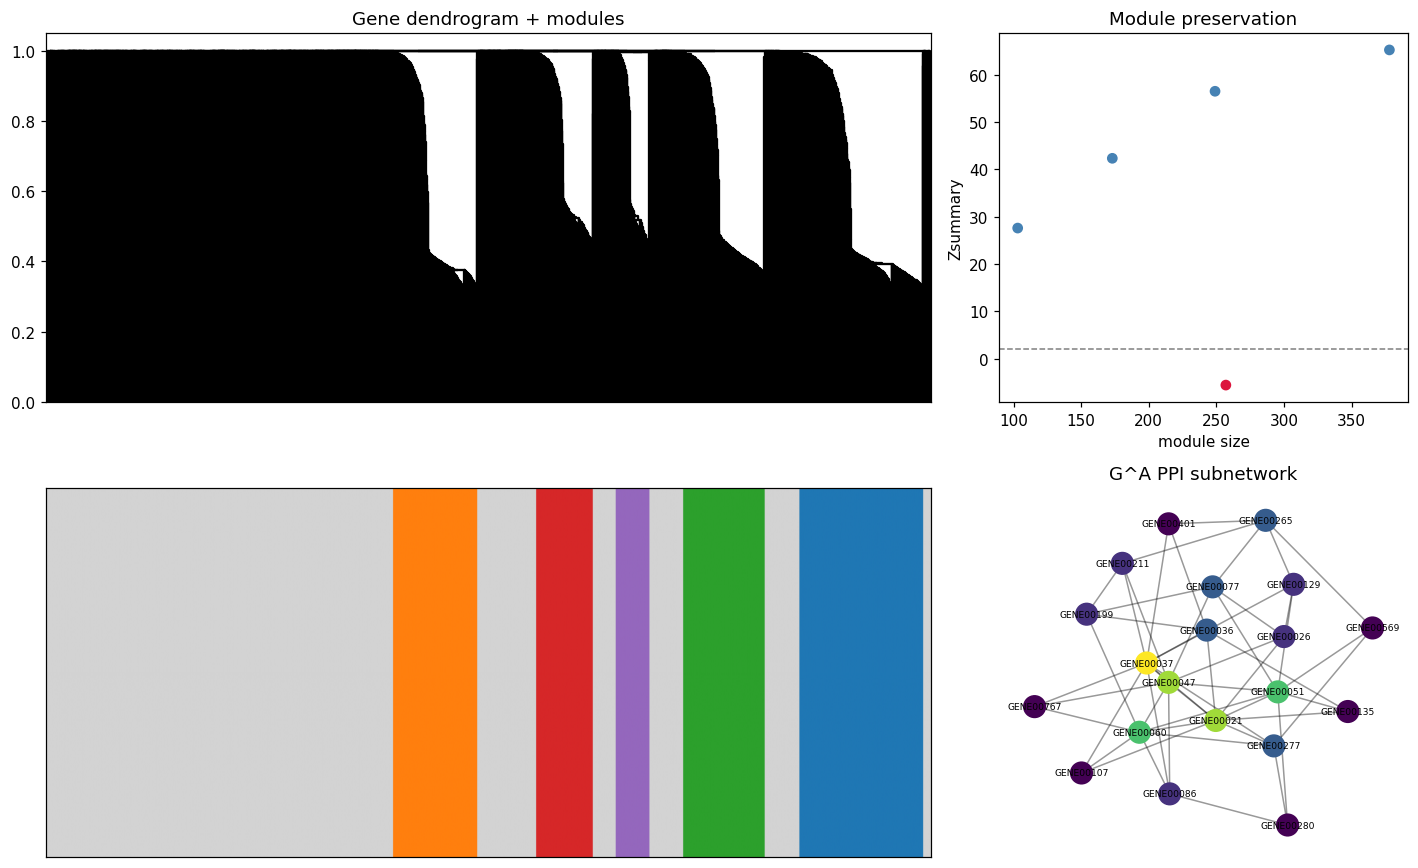

In [6]:
# Fig. 3/4/5 analogues
fig, axes = plt.subplot_mosaic("AAB;CCD", figsize=(13, 8))

labels, Z = fa_diag["labels"], fa_diag["Z"]
palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
label_to_color = {0: "lightgrey"}
for i, lab in enumerate(sorted(set(labels) - {0})):
    label_to_color[lab] = palette[i % len(palette)]
dn = dendrogram(Z, ax=axes["A"], no_labels=True, color_threshold=0, above_threshold_color="black")
axes["A"].set_title("Gene dendrogram + modules")
order = dn["leaves"]
color_arr = mcolors.to_rgba_array([label_to_color[labels[i]] for i in order]).reshape(1, -1, 4)
axes["C"].imshow(color_arr, aspect="auto"); axes["C"].set_yticks([]); axes["C"].set_xticks([])

pres = fa_diag["preservation"]
axes["B"].scatter(pres["size"], pres["Zsummary"],
                   c=["crimson" if z < cfg.ZSUMMARY_CUTOFF else "steelblue" for z in pres.Zsummary])
axes["B"].axhline(cfg.ZSUMMARY_CUTOFF, color="grey", linestyle="--", linewidth=1)
axes["B"].set_xlabel("module size"); axes["B"].set_ylabel("Zsummary"); axes["B"].set_title("Module preservation")

sub = fa_diag["ppi"].subgraph(G_A)
pos = nx.spring_layout(sub, seed=cfg.RANDOM_STATE)
deg = dict(sub.degree())
nx.draw_networkx_edges(sub, pos, ax=axes["D"], alpha=0.4)
nx.draw_networkx_nodes(sub, pos, ax=axes["D"], node_color=[deg[n] for n in sub.nodes()],
                        cmap="viridis", node_size=200)
nx.draw_networkx_labels(sub, pos, ax=axes["D"], font_size=6)
axes["D"].set_title("G^A PPI subnetwork"); axes["D"].axis("off")
plt.tight_layout()
plt.show()

## DMN_miRNA

In [7]:
# Table 3 of Rastegari et al. (2023) — used as offline fallback / validation data
PAPER_TABLE3_EDGES = (
    [("hsa-mir-155-5p", g) for g in
     ["CDK4", "ACTB", "TNF", "CAT", "TP53", "RAC2", "RPLP0", "CDKN1A", "EEF2", "CCL2"]]
    + [("hsa-mir-17-5p", g) for g in
       ["MAPK3", "TNF", "TLR7", "ACTB", "CDK4", "TP53", "CCL5", "CDKN1A"]]
    + [("hsa-mir-181a-5p", g) for g in
       ["MAPK3", "ACTB", "CTSD", "TP53", "RPLP0", "CDKN1A", "CD4"]]
    + [("hsa-mir-18a-5p", g) for g in
       ["CDK4", "ACTB", "TP53", "RACK1", "CDKN1A", "EEF2"]]
    + [("hsa-mir-92a-1-5p", g) for g in
       ["CD74", "TP53", "CDKN1A", "EEF2"]]
)
PAPER_PUBLISHED_ANSWER = {"hsa-mir-155-5p", "hsa-mir-17-5p", "hsa-mir-181a-5p",
                           "hsa-mir-18a-5p", "hsa-mir-92a-1-5p"}


def build_mirna_gene_bipartite(edges):
    G = nx.Graph()
    for mi, g in edges:
        G.add_node(mi, bipartite="miRNA")
        G.add_node(g, bipartite="gene")
        G.add_edge(mi, g)
    return G


def load_mirna_gene_network(target_genes, local_path=None):
    """Local CSV -> live miRNet API -> paper Table 3 fallback."""
    if local_path is not None and Path(local_path).exists():
        df = pd.read_csv(local_path)
        return build_mirna_gene_bipartite(list(zip(df["mirna"], df["gene"]))), "local_file"

    try:
        import requests
        resp = requests.post("https://api.mirnet.ca/table/gene",
                              json={"org": "hsa", "idOpt": "symbol",
                                    "myList": "\n".join(target_genes), "targetOpt": "mirna"}, timeout=8)
        resp.raise_for_status()
        edges = [(row["mir_id"], row["symbol"]) for row in resp.json()]
        if edges:
            return build_mirna_gene_bipartite(edges), "mirnet_api"
    except Exception:
        pass

    edges = [(mi, g) for mi, g in PAPER_TABLE3_EDGES if g in set(target_genes)]
    return build_mirna_gene_bipartite(edges), "paper_table3_fallback"


def extended_greedy_set_cover(G_miR, target_genes):
    """Extended greedy set cover (Fig. 2): sort miRNAs by fixed degree, single pass."""
    target_genes = set(target_genes)
    mirnas_all = [n for n, d in G_miR.nodes(data=True) if d.get("bipartite") == "miRNA"]
    reachable = {g for g in target_genes
                 if g in G_miR and any(nb in mirnas_all for nb in G_miR.neighbors(g))}

    R_sorted = sorted(mirnas_all, key=lambda m: G_miR.degree(m), reverse=True)
    R_result, covered = [], set()
    for r in R_sorted:
        if covered == reachable:
            break
        neighbours = set(G_miR.neighbors(r)) & reachable
        if neighbours - covered:
            covered |= neighbours
            R_result.append(r)
    return R_result, covered, target_genes - reachable


def DMN_miRNA(G_A, cfg, local_mirna_path=None):
    G_miR, source = load_mirna_gene_network(G_A, local_path=local_mirna_path)
    R_result, covered, unreachable = extended_greedy_set_cover(G_miR, G_A)
    return R_result, dict(G_miR=G_miR, source=source, covered=covered, unreachable=unreachable)

In [8]:
# Validate against the paper's own published result
R_check, covered, _ = extended_greedy_set_cover(
    build_mirna_gene_bipartite(PAPER_TABLE3_EDGES), {g for _, g in PAPER_TABLE3_EDGES})
assert set(R_check) == PAPER_PUBLISHED_ANSWER
print("validated: extended_greedy_set_cover reproduces paper Table 3 exactly")

validated: extended_greedy_set_cover reproduces paper Table 3 exactly


In [9]:
# Worked example on the paper's own G^A gene symbols (Table 2), since the
# demo's simulated gene names won't match any offline mRNA-miRNA database
paper_G_A = ["TP53", "TNF", "MAPK3", "ACTB", "TLR7", "LCK", "RAC2", "EEF2", "CAT",
             "ZAP70", "CD19", "RPLP0", "CDKN1A", "CCL2", "CDK4", "CCL5", "CTSD",
             "CD4", "RACK1", "CD74"]

mirna_edges_file = cfg.DATA_DIR / "mirna_gene_edges.csv"
R, mirna_diag = DMN_miRNA(paper_G_A, cfg,
                           local_mirna_path=mirna_edges_file if mirna_edges_file.exists() else None)

print("source:", mirna_diag["source"])
print(f"R ({len(R)} miRNAs): {sorted(R)}")
for m in sorted(R):
    targets = sorted(set(mirna_diag["G_miR"].neighbors(m)) & set(paper_G_A))
    print(f"  {m:<18} degree={mirna_diag['G_miR'].degree(m):<3} targets={targets}")

source: paper_table3_fallback
R (5 miRNAs): ['hsa-mir-155-5p', 'hsa-mir-17-5p', 'hsa-mir-181a-5p', 'hsa-mir-18a-5p', 'hsa-mir-92a-1-5p']
  hsa-mir-155-5p     degree=10  targets=['ACTB', 'CAT', 'CCL2', 'CDK4', 'CDKN1A', 'EEF2', 'RAC2', 'RPLP0', 'TNF', 'TP53']
  hsa-mir-17-5p      degree=8   targets=['ACTB', 'CCL5', 'CDK4', 'CDKN1A', 'MAPK3', 'TLR7', 'TNF', 'TP53']
  hsa-mir-181a-5p    degree=7   targets=['ACTB', 'CD4', 'CDKN1A', 'CTSD', 'MAPK3', 'RPLP0', 'TP53']
  hsa-mir-18a-5p     degree=6   targets=['ACTB', 'CDK4', 'CDKN1A', 'EEF2', 'RACK1', 'TP53']
  hsa-mir-92a-1-5p   degree=4   targets=['CD74', 'CDKN1A', 'EEF2', 'TP53']


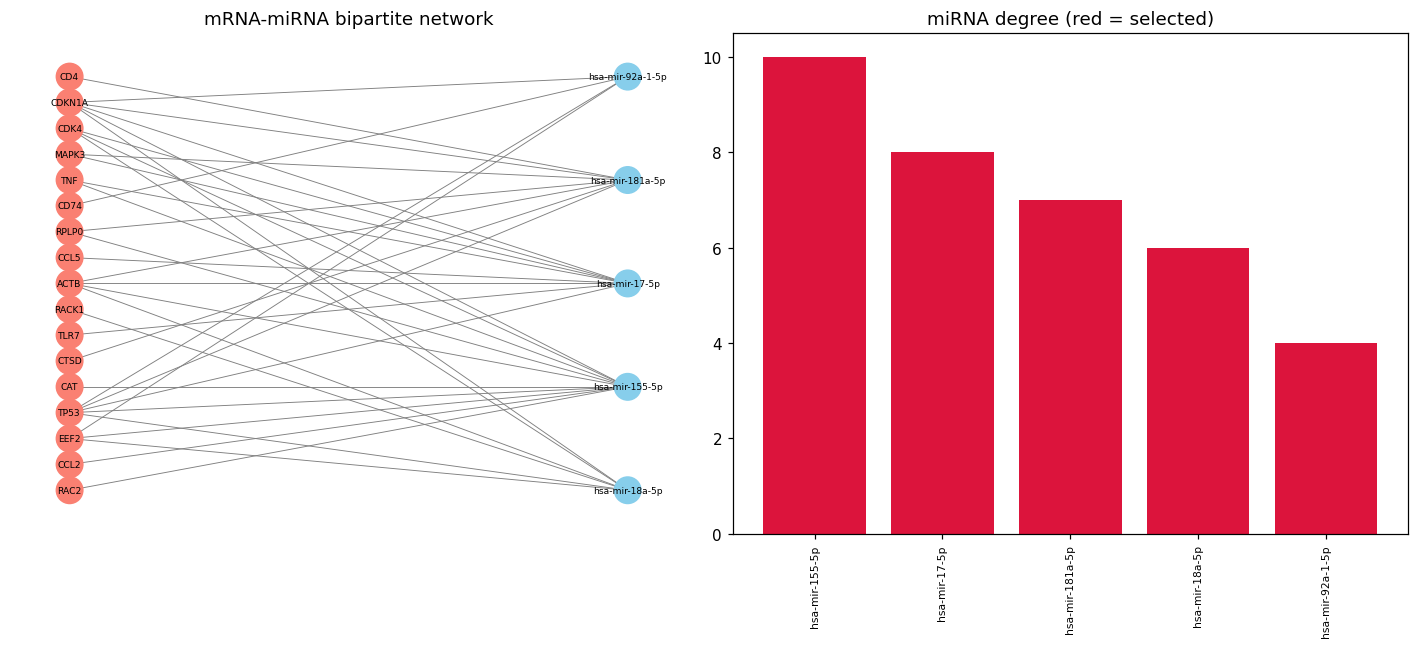

In [10]:
# Fig. 6 analogue
if mirna_diag["G_miR"].number_of_edges() > 0:
    B = mirna_diag["G_miR"]
    gene_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == "gene"]
    mirna_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == "miRNA"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    pos = nx.bipartite_layout(B, gene_nodes)
    colors = ["salmon" if n in gene_nodes else "skyblue" for n in B.nodes()]
    nx.draw(B, pos, ax=axes[0], with_labels=True, node_color=colors, font_size=6,
            node_size=300, edge_color="grey", width=0.6)
    axes[0].set_title("mRNA-miRNA bipartite network")

    deg_series = pd.Series({m: B.degree(m) for m in mirna_nodes}).sort_values(ascending=False)
    bar_colors = ["crimson" if m in R else "lightsteelblue" for m in deg_series.index]
    axes[1].bar(range(len(deg_series)), deg_series.values, color=bar_colors)
    axes[1].set_xticks(range(len(deg_series)))
    axes[1].set_xticklabels(deg_series.index, rotation=90, fontsize=7)
    axes[1].set_title("miRNA degree (red = selected)")
    plt.tight_layout()
    plt.show()

## Full pipeline

In [11]:
def run_full_pipeline(ESC, ESA, cfg, ppi_edges_path=None, mirna_edges_path=None):
    G_A, fa_diag = FA_gene(ESC, ESA, cfg, ppi_edges_path=ppi_edges_path)
    R, mirna_diag = DMN_miRNA(G_A, cfg, local_mirna_path=mirna_edges_path)
    return dict(G_A=G_A, R=R, fa_diagnostics=fa_diag, mirna_diagnostics=mirna_diag)


results = run_full_pipeline(
    ESC, ESA, cfg,
    ppi_edges_path=(cfg.DATA_DIR / "ppi_edges.csv") if (cfg.DATA_DIR / "ppi_edges.csv").exists() else None,
    mirna_edges_path=(cfg.DATA_DIR / "mirna_gene_edges.csv") if (cfg.DATA_DIR / "mirna_gene_edges.csv").exists() else None,
)
print(f"G^A ({len(results['G_A'])}):", results["G_A"])
print(f"R ({len(results['R'])}):", sorted(results["R"]))

..cutHeight not given, setting it to 0.9935001378050203  ===>  99% of the (truncated) height range in dendro.


G^A (20): ['GENE00037', 'GENE00051', 'GENE00047', 'GENE00060', 'GENE00021', 'GENE00107', 'GENE00129', 'GENE00036', 'GENE00401', 'GENE00077', 'GENE00199', 'GENE00026', 'GENE00211', 'GENE00265', 'GENE00086', 'GENE00277', 'GENE00767', 'GENE00569', 'GENE00135', 'GENE00280']
R (0): []
